Gemma 3
====

 * Gated model aggreement

![Gated Model License](../assets/hf-gated-model-license.png)

```bash
pip install --upgrade transformers  # required
```

### Inference using the pipeline

In [1]:
import base64
from io import BytesIO
from PIL import Image
import torch
from transformers import pipeline

pipe = pipeline(
    "image-text-to-text",
    model="google/gemma-3-4b-it",
    device="cuda",
    torch_dtype=torch.bfloat16
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

In [2]:
import base64
from io import BytesIO
from PIL import Image

image1 = Image.open("../samples/fruits-01.jpg")

def load_image_as_base64(image):
    buffer = BytesIO()
    image.save(buffer, format="JPEG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

image1_base64 = load_image_as_base64(image1)

In [3]:
messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are a helpful assistant."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "data:image/jpeg;base64," + image1_base64},
            {"type": "text", "text": "What fruits and vegetables do you see in this image?"}
        ]
    }
]

output = pipe(text=messages, max_new_tokens=200)
print(output[0]["generated_text"][-1]["content"])

[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Okay, let’s identify the fruits and vegetables in the image!

I see the following:

*   **Blueberries:** A cluster of dark blue berries.
*   **Raspberries:** A small bunch of bright red raspberries.
*   **Cucumbers:** Three green cucumbers.

Would you like me to tell you anything more about these items, like their nutritional value or how to prepare them?


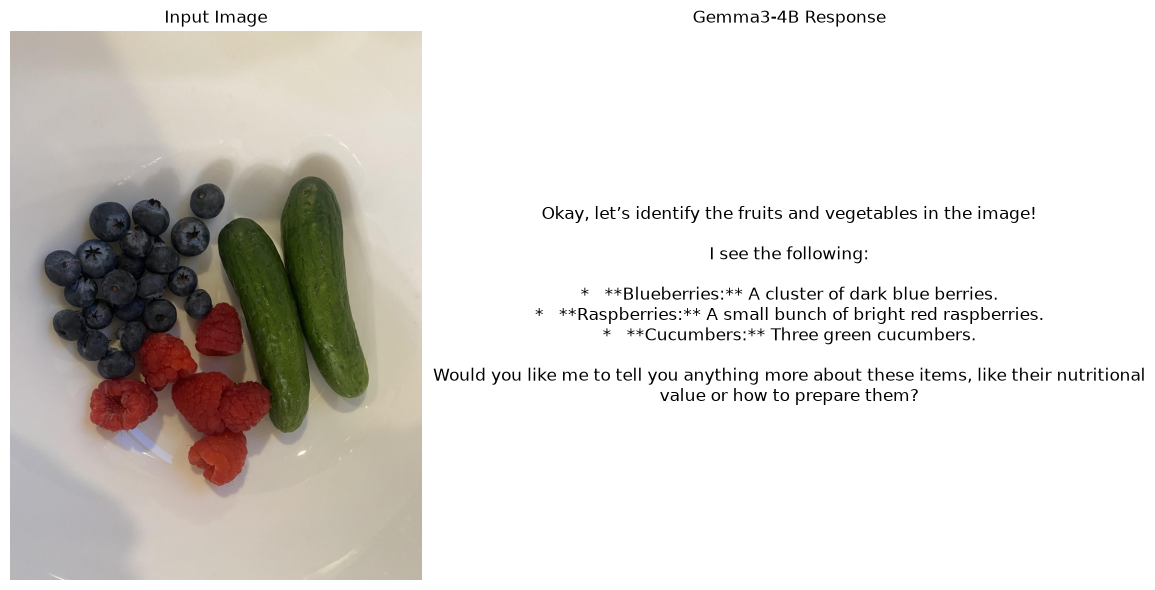

In [4]:
import matplotlib.pyplot as plt

response = output[0]["generated_text"][-1]["content"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image1)
axes[0].axis("off")
axes[0].set_title("Input Image")
axes[1].text(
    0.5, 0.5, response,
    fontsize=12, ha="center", va="center", wrap=True
)
axes[1].axis("off")
axes[1].set_title("Gemma3-4B Response")
plt.tight_layout()
plt.show()

### Directly inference with model

In [5]:
# pip install accelerate

from transformers import AutoProcessor, Gemma3ForConditionalGeneration

model_id = "google/gemma-3-4b-it"

model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id, device_map="auto"
).eval()

processor = AutoProcessor.from_pretrained(model_id)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

In [6]:
image2 = Image.open("../samples/plants.jpg")
image2_base64 = load_image_as_base64(image2)

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are a helpful assistant."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "data:image/jpeg;base64," + image2_base64},
            {"type": "text", "text": "Describe this image in detail."}
        ]
    }
]

inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt"
).to(model.device, dtype=torch.bfloat16)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=100, do_sample=False)
    generation = generation[0][input_len:]

decoded = processor.decode(generation, skip_special_tokens=True)
print(decoded)

Okay, here's a detailed description of the image:

**Overall Impression:**

The image showcases two potted plants displayed against a plain white wall. The plants are elevated using decorative, gold-colored wire plant stands. The overall aesthetic is modern and slightly minimalist.

**Detailed Breakdown:**

*   **Plants:** There are two plants visible.
    *   **Left Plant:** A smaller, darker green plant with glossy leaves. It’s in a dark blue pot with a gold


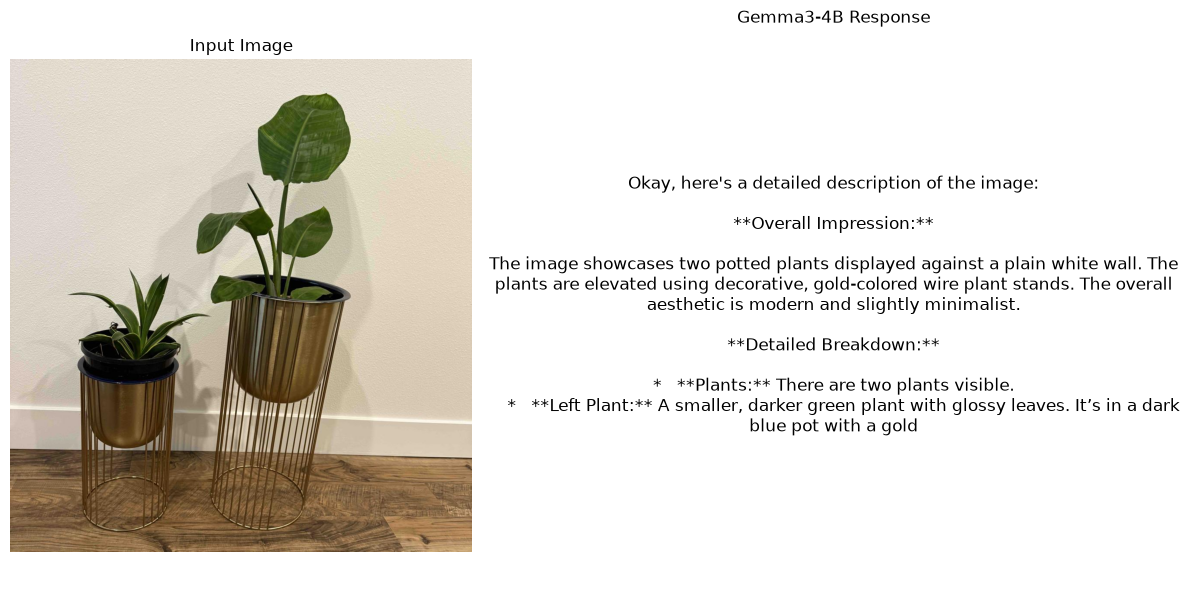

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image2)
axes[0].axis("off")
axes[0].set_title("Input Image")
axes[1].text(
    0.5, 0.5, decoded,
    fontsize=12, ha="center", va="center", wrap=True
)
axes[1].axis("off")
axes[1].set_title("Gemma3-4B Response")
plt.tight_layout()
plt.show()